# MedvCNN — Customized CNN for Medical Data Classification (MedMNIST v2)

This notebook reproduces the thesis **"Customized Convolutional Neural Network Architecture
for Medical Data Classification"** end-to-end. It is self-contained: run it top-to-bottom in
Colab or Jupyter. It builds on the official MedMNIST starter and adds the full pipeline the
report describes — data augmentation, the **MedvCNN** model, training, and the complete
evaluation suite (AUC, ACC, confusion matrix, per-class Precision/Recall/F1, ROC curves) and
the ablation study.

**Sections**
1. Setup
2. Configuration
3. Data processing & augmentation (report §3.4.1)
4. The MedvCNN model (report §3.4.3)
5. Loss & optimizer (report §3.4)
6. Training (report §4)
7. Evaluation: AUC/ACC, confusion matrix, P/R/F1, ROC (report §4.5)
8. Ablation study (report §4.4.2)

## 1. Setup

In [1]:
!pip install -q medmnist scikit-learn seaborn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 115.9/115.9 kB 7.0 MB/s eta 0:00:00


In [2]:
from tqdm import tqdm
from itertools import cycle
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import torch.utils.data as data
import torchvision.transforms as transforms

import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import (confusion_matrix, ConfusionMatrixDisplay,
                             classification_report, roc_curve, auc, roc_auc_score,
                             accuracy_score)

import medmnist
from medmnist import INFO, Evaluator

print(f"MedMNIST v{medmnist.__version__} @ {medmnist.HOMEPAGE}")

def set_seed(seed=42):
    np.random.seed(seed); torch.manual_seed(seed); torch.cuda.manual_seed_all(seed)
set_seed(42)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

MedMNIST v3.0.2 @ https://github.com/MedMNIST/MedMNIST/
Device: cuda


## 2. Configuration

The report analyses seven MedMNIST v2 datasets. Pick one here. Defaults follow the paper:
batch size 128, SGD, lr = 0.001, momentum = 0.9, 50 epochs. Lower `NUM_EPOCHS` for a quick trial.

In [3]:
data_flag  = "pathmnist"   # try: pathmnist, chestmnist, tissuemnist, organamnist,
                           #      pneumoniamnist, breastmnist, octmnist
download   = True
NUM_EPOCHS = 50
BATCH_SIZE = 128
lr         = 0.001
momentum   = 0.9
AUGMENT    = True          # flip / rotate / translate augmentation
SIZE       = 28            # 28 reproduces the report

info       = INFO[data_flag]
task       = info["task"]
n_channels = info["n_channels"]
n_classes  = len(info["label"])
labels     = info["label"]
DataClass  = getattr(medmnist, info["python_class"])
print(f"task={task} | channels={n_channels} | classes={n_classes}")

task=multi-class | channels=3 | classes=9


## 3. Data processing & augmentation (report §3.4.1)

Images are converted to tensors and normalized to **[-1, 1]** with mean = std = 0.5.
For training we optionally add horizontal/vertical flips and a random rotation + translation
(affine) — the augmentations the report uses to enrich datasets with few samples.

In [4]:
mean, std = [0.5]*n_channels, [0.5]*n_channels

train_ops = []
if AUGMENT:
    train_ops += [transforms.RandomHorizontalFlip(0.5),
                  transforms.RandomVerticalFlip(0.5),
                  transforms.RandomAffine(degrees=15, translate=(0.1, 0.1))]
train_ops += [transforms.ToTensor(), transforms.Normalize(mean, std)]
train_tf = transforms.Compose(train_ops)
eval_tf  = transforms.Compose([transforms.ToTensor(), transforms.Normalize(mean, std)])

common = dict(download=download)
if SIZE != 28:
    common.update(size=SIZE, mmap_mode="r")

train_dataset = DataClass(split="train", transform=train_tf, **common)
val_dataset   = DataClass(split="val",   transform=eval_tf,  **common)
test_dataset  = DataClass(split="test",  transform=eval_tf,  **common)

train_loader          = data.DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
train_loader_at_eval  = data.DataLoader(train_dataset, batch_size=2*BATCH_SIZE, shuffle=False)
val_loader            = data.DataLoader(val_dataset,   batch_size=2*BATCH_SIZE, shuffle=False)
test_loader           = data.DataLoader(test_dataset,  batch_size=2*BATCH_SIZE, shuffle=False)

print(train_dataset)

100%|██████████| 206M/206M [01:22<00:00, 2.49MB/s]


Dataset PathMNIST of size 28 (pathmnist)
    Number of datapoints: 89996
    Root location: /root/.medmnist
    Split: train
    Task: multi-class
    Number of channels: 3
    Meaning of labels: {'0': 'adipose', '1': 'background', '2': 'debris', '3': 'lymphocytes', '4': 'mucus', '5': 'smooth muscle', '6': 'normal colon mucosa', '7': 'cancer-associated stroma', '8': 'colorectal adenocarcinoma epithelium'}
    Number of samples: {'train': 89996, 'val': 10004, 'test': 7180}
    Description: The PathMNIST is based on a prior study for predicting survival from colorectal cancer histology slides, providing a dataset (NCT-CRC-HE-100K) of 100,000 non-overlapping image patches from hematoxylin & eosin stained histological images, and a test dataset (CRC-VAL-HE-7K) of 7,180 image patches from a different clinical center. The dataset is comprised of 9 types of tissues, resulting in a multi-class classification task. We resize the source images of 3×224×224 into 3×28×28, and split NCT-CRC-HE-100K

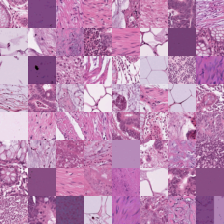

In [5]:
# Visualize a sample montage
DataClass(split="train", download=download).montage(length=8)

## 4. The MedvCNN model (report §3.4.3)

Five 3×3 convolutional groups (ReLU + BatchNorm), with max-pooling after groups 2 and 5,
then a three-layer fully connected head (128 → 128 → num_classes). On 28×28 inputs the
features reaching the head are 64×4×4 = 1024, exactly as the report specifies. An
`AdaptiveAvgPool2d((4,4))` keeps that dimension fixed for other input sizes.

In [6]:
def pool(kind="max"):
    return nn.MaxPool2d(2, 2) if kind == "max" else nn.AvgPool2d(2, 2)

class MedvCNN(nn.Module):
    def __init__(self, in_channels, num_classes, pool_type="max"):
        super().__init__()
        self.layer1 = nn.Sequential(nn.Conv2d(in_channels, 16, 3), nn.BatchNorm2d(16), nn.ReLU(True))
        self.layer2 = nn.Sequential(nn.Conv2d(16, 16, 3), nn.BatchNorm2d(16), nn.ReLU(True), pool(pool_type))
        self.layer3 = nn.Sequential(nn.Conv2d(16, 64, 3), nn.BatchNorm2d(64), nn.ReLU(True))
        self.layer4 = nn.Sequential(nn.Conv2d(64, 64, 3), nn.BatchNorm2d(64), nn.ReLU(True))
        self.layer5 = nn.Sequential(nn.Conv2d(64, 64, 3, padding=1), nn.BatchNorm2d(64), nn.ReLU(True), pool(pool_type))
        self.gap = nn.AdaptiveAvgPool2d((4, 4))
        self.fc  = nn.Sequential(nn.Linear(64*4*4, 128), nn.ReLU(True),
                                 nn.Linear(128, 128),    nn.ReLU(True),
                                 nn.Linear(128, num_classes))
    def forward(self, x):
        for l in (self.layer1, self.layer2, self.layer3, self.layer4, self.layer5):
            x = l(x)
        x = self.gap(x).view(x.size(0), -1)
        return self.fc(x)

model = MedvCNN(n_channels, n_classes).to(device)
print(model)
print("Trainable parameters:", sum(p.numel() for p in model.parameters()))

MedvCNN(
  (layer1): Sequential(
    (0): Conv2d(3, 16, kernel_size=(3, 3), stride=(1, 1))
    (1): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
  )
  (layer2): Sequential(
    (0): Conv2d(16, 16, kernel_size=(3, 3), stride=(1, 1))
    (1): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (layer3): Sequential(
    (0): Conv2d(16, 64, kernel_size=(3, 3), stride=(1, 1))
    (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
  )
  (layer4): Sequential(
    (0): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1))
    (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
  )
  (layer5): Sequential(
    (0): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(

## 5. Loss & optimizer (report §3.4)

In [7]:
criterion = nn.BCEWithLogitsLoss() if task == "multi-label, binary-class" else nn.CrossEntropyLoss()
optimizer = optim.SGD(model.parameters(), lr=lr, momentum=momentum)

## 6. Training (report §4)

Each epoch trains on the training split and reports validation AUC/ACC via the official
MedMNIST `Evaluator`. The weights with the best validation AUC are kept.

In [8]:
def prep_targets(targets):
    if task == "multi-label, binary-class":
        return targets.to(torch.float32)
    return targets.squeeze().long()

@torch.no_grad()
def collect_predictions(loader):
    model.eval()
    y_true, y_score = torch.tensor([]), torch.tensor([])
    for inputs, targets in loader:
        outputs = model(inputs.to(device)).cpu()
        if task == "multi-label, binary-class":
            targets = targets.to(torch.float32); outputs = outputs.sigmoid()
        else:
            targets = targets.squeeze().long(); outputs = outputs.softmax(-1)
            targets = targets.float().resize_(len(targets), 1)
        y_true  = torch.cat((y_true, targets), 0)
        y_score = torch.cat((y_score, outputs), 0)
    return y_true.numpy(), y_score.numpy()

def eval_auc_acc(loader, split):
    _, y_score = collect_predictions(loader)
    return Evaluator(data_flag, split, size=SIZE).evaluate(y_score)

best_auc, best_state = -1, None
for epoch in range(NUM_EPOCHS):
    model.train(); running = 0.0
    for inputs, targets in tqdm(train_loader, leave=False, desc=f"epoch {epoch+1}"):
        inputs, targets = inputs.to(device), prep_targets(targets).to(device)
        optimizer.zero_grad()
        loss = criterion(model(inputs), targets)
        loss.backward(); optimizer.step()
        running += loss.item()
    v_auc, v_acc = eval_auc_acc(val_loader, "val")
    print(f"epoch {epoch+1:02d}  loss={running/len(train_loader):.4f}  val_auc={v_auc:.3f}  val_acc={v_acc:.3f}")
    if v_auc > best_auc:
        best_auc = v_auc
        best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}

if best_state:
    model.load_state_dict(best_state)
print("Best validation AUC:", round(best_auc, 3))

epoch 01  loss=1.1269  val_auc=0.966  val_acc=0.749


epoch 02  loss=0.6153  val_auc=0.976  val_acc=0.781


epoch 03  loss=0.4937  val_auc=0.983  val_acc=0.799


epoch 04  loss=0.4198  val_auc=0.984  val_acc=0.822


epoch 05  loss=0.3734  val_auc=0.985  val_acc=0.785


...

epoch 46  loss=0.1127  val_auc=0.995  val_acc=0.858


epoch 47  loss=0.1165  val_auc=0.999  val_acc=0.958


epoch 48  loss=0.1071  val_auc=0.999  val_acc=0.969


epoch 49  loss=0.1079  val_auc=0.999  val_acc=0.959


epoch 50  loss=0.1063  val_auc=0.999  val_acc=0.959
Best validation AUC: 0.999


In [9]:
# Official MedMNIST test AUC / ACC
test_auc, test_acc = eval_auc_acc(test_loader, "test")
print(f"TEST  auc={test_auc:.3f}  acc={test_acc:.3f}")

TEST  auc=0.979  acc=0.849


## 7. Evaluation: confusion matrix, P/R/F1, ROC (report §4.5)

Single-label datasets get an argmax confusion matrix, a per-class Precision/Recall/F1 report
(the Table-11 style output), and ROC curves. Multi-label ChestMNIST is scored per label.

Accuracy: 0.8492

Per-class Precision / Recall / F1:

                                      precision    recall  f1-score   support

                             adipose     0.9215    0.8864    0.9036      1338
                          background     0.9117    1.0000    0.9538       847
                              debris     0.5466    0.9174    0.6850       339
                         lymphocytes     0.9799    0.9227    0.9504       634
                               mucus     0.9675    0.7758    0.8611      1035
                       smooth muscle     0.6647    0.7804    0.7179       592
                 normal colon mucosa     0.8166    0.7449    0.7791       741
            cancer-associated stroma     0.7696    0.4204    0.5438       421
colorectal adenocarcinoma epithelium     0.8588    0.9521    0.9031      1233

                            accuracy                         0.8492      7180
                           macro avg     0.8263    0.8223    0.8109      7180
        

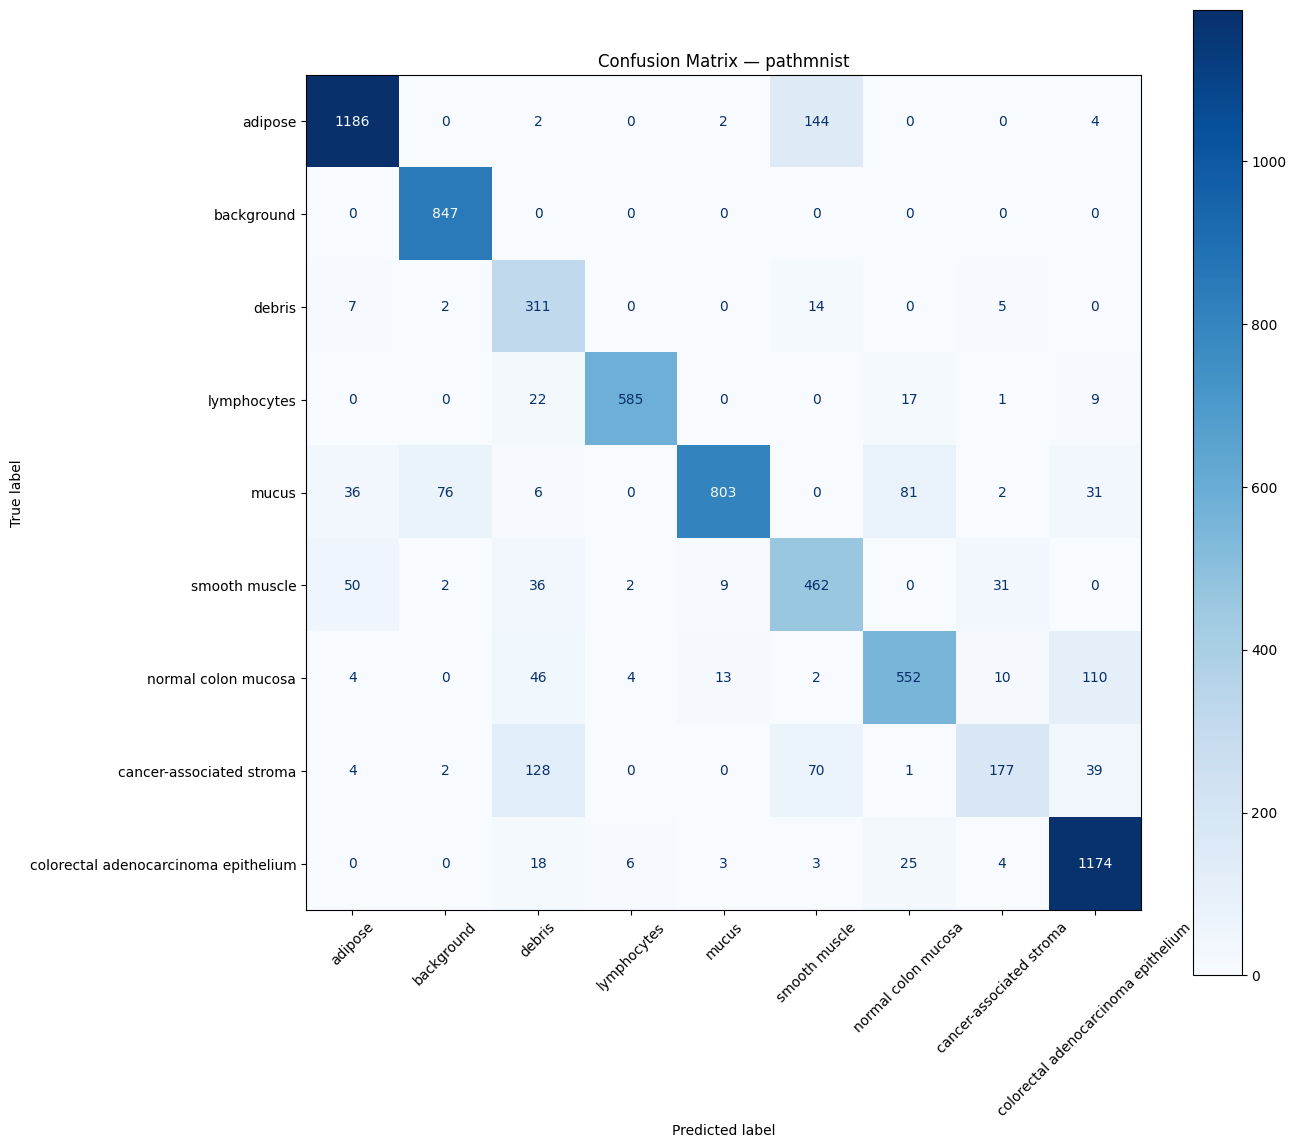

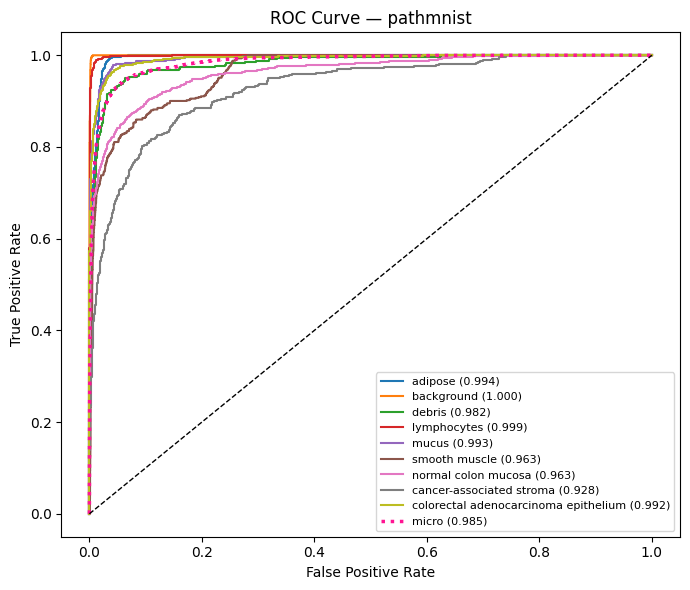

In [10]:
names = [labels.get(str(i), str(i)) for i in range(n_classes)]
y_true, y_score = collect_predictions(test_loader)

if task == "multi-label, binary-class":
    y_pred = (y_score >= 0.5).astype(int)
    print("Per-label Precision / Recall / F1:\n")
    print(classification_report(y_true, y_pred, target_names=names, digits=4, zero_division=0))
    print("Macro AUC:", round(roc_auc_score(y_true, y_score, average="macro"), 4))

    plt.figure(figsize=(8, 6))
    for i, c in zip(range(n_classes), cycle(plt.cm.tab20.colors)):
        if y_true[:, i].sum() == 0: continue
        fpr, tpr, _ = roc_curve(y_true[:, i], y_score[:, i])
        plt.plot(fpr, tpr, lw=1.2, color=c, label=f"{names[i]} ({auc(fpr, tpr):.3f})")
    plt.plot([0,1],[0,1],"k--",lw=1)
    plt.xlabel("False Positive Rate"); plt.ylabel("True Positive Rate")
    plt.title(f"Per-label ROC — {data_flag}"); plt.legend(fontsize=7, ncol=2, loc="lower right")
    plt.tight_layout(); plt.show()
else:
    yt = y_true.astype(int).ravel(); yp = y_score.argmax(1)
    print("Accuracy:", round(accuracy_score(yt, yp), 4))
    print("\nPer-class Precision / Recall / F1:\n")
    print(classification_report(yt, yp, target_names=names, digits=4, zero_division=0))

    cm = confusion_matrix(yt, yp)
    fig, ax = plt.subplots(figsize=(1.3*n_classes+2, 1.1*n_classes+2))
    ConfusionMatrixDisplay(cm, display_labels=names).plot(ax=ax, cmap="Blues", xticks_rotation=45)
    ax.set_title(f"Confusion Matrix — {data_flag}"); plt.tight_layout(); plt.show()

    plt.figure(figsize=(7, 6))
    if n_classes == 2:
        fpr, tpr, _ = roc_curve(yt, y_score[:, 1])
        plt.plot(fpr, tpr, lw=2, label=f"ROC (AUC = {auc(fpr, tpr):.3f})")
    else:
        onehot = np.eye(n_classes)[yt]
        for i, c in zip(range(n_classes), cycle(plt.cm.tab10.colors)):
            fpr, tpr, _ = roc_curve(onehot[:, i], y_score[:, i])
            plt.plot(fpr, tpr, lw=1.5, color=c, label=f"{names[i]} ({auc(fpr, tpr):.3f})")
        fpr, tpr, _ = roc_curve(onehot.ravel(), y_score.ravel())
        plt.plot(fpr, tpr, lw=2.5, ls=":", color="deeppink", label=f"micro ({auc(fpr, tpr):.3f})")
    plt.plot([0,1],[0,1],"k--",lw=1)
    plt.xlabel("False Positive Rate"); plt.ylabel("True Positive Rate")
    plt.title(f"ROC Curve — {data_flag}"); plt.legend(fontsize=8, loc="lower right")
    plt.tight_layout(); plt.show()

## 8. Ablation study (report §4.4.2)

Two cases from the paper. Keep the epoch count small here since each configuration trains
from scratch.

* **CASE 1** — pooling: MaxPool2D vs AvgPool2D.
* **CASE 4** — optimizer × learning rate: {SGD, Adam} × {1e-5, 1e-4, 1e-3}.

In [11]:
ABLATION_EPOCHS = 5   # raise for closer-to-report numbers

def train_quick(pool_type="max", opt_name="sgd", lr_=0.001, epochs=ABLATION_EPOCHS):
    set_seed(42)
    m = MedvCNN(n_channels, n_classes, pool_type=pool_type).to(device)
    crit = nn.BCEWithLogitsLoss() if task=="multi-label, binary-class" else nn.CrossEntropyLoss()
    opt = (optim.SGD(m.parameters(), lr=lr_, momentum=0.9) if opt_name=="sgd"
           else optim.Adam(m.parameters(), lr=lr_))
    for _ in range(epochs):
        m.train()
        for inputs, targets in train_loader:
            inputs, targets = inputs.to(device), prep_targets(targets).to(device)
            opt.zero_grad(); crit(m(inputs), targets).backward(); opt.step()
    # temporarily swap global model for evaluation helpers
    global model; saved = model; model = m
    ta, tc = eval_auc_acc(test_loader, "test")
    model = saved
    return ta, tc

print("CASE 1 — Pooling")
for p in ("max", "avg"):
    a, c = train_quick(pool_type=p)
    print(f"  {p:>3}  test_auc={a:.3f}  test_acc={c:.3f}")

print("\nCASE 4 — Optimizer x Learning rate")
for opt_name in ("sgd", "adam"):
    for lr_ in (1e-5, 1e-4, 1e-3):
        a, c = train_quick(opt_name=opt_name, lr_=lr_)
        print(f"  {opt_name:>4}  lr={lr_:<7}  test_auc={a:.3f}  test_acc={c:.3f}")

CASE 1 — Pooling
  max  test_auc=0.967  test_acc=0.715
  avg  test_auc=0.944  test_acc=0.666

CASE 4 — Optimizer x Learning rate
   sgd  lr=1e-05    test_auc=0.790  test_acc=0.414
   sgd  lr=0.0001   test_auc=0.937  test_acc=0.713
   sgd  lr=0.001    test_auc=0.967  test_acc=0.734
  adam  lr=1e-05    test_auc=0.952  test_acc=0.755
  adam  lr=0.0001   test_auc=0.963  test_acc=0.780
  adam  lr=0.001    test_auc=0.972  test_acc=0.824
